# Day 4 · Notebook 2 — CNNs and transfer learning
### ML Bootcamp · Day 4 of 5

In Notebook 1 our dense network flattened each picture into a line of numbers — it had no idea which pixels are **next to each other**. A **Convolutional Neural Network (CNN)** keeps the picture's shape and looks for small patterns.

In this notebook you will:
1. See how **colour images** are stored as numbers *(Part 1)*
2. Run a **convolution** yourself: build an edge detector by hand *(Part 2)*
3. Train a **CNN** on Fashion-MNIST, beat the dense network, and look **inside** it *(Part 3)*
4. **Transfer learning**: a pre-trained model vs one trained from scratch *(Part 4)*

> ⚡ Runtime → Change runtime type → **T4 GPU**. Run cells in order with **Shift + Enter**. ✍️ = exercise (solutions at the end).

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import cv2
import tensorflow as tf
import keras
from keras import layers
sns.set_theme(style="white")
keras.utils.set_random_seed(42)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

GPU available: True


---
## Part 1 · Images are numbers
A **colour** image has **3 numbers per pixel**: how much **Red**, **Green** and **Blue**. Let's download a photo.

Shape (height, width, channels): (1080, 810, 3)
Total numbers: 2624400
Top-left pixel [R, G, B]: [172 146 119]


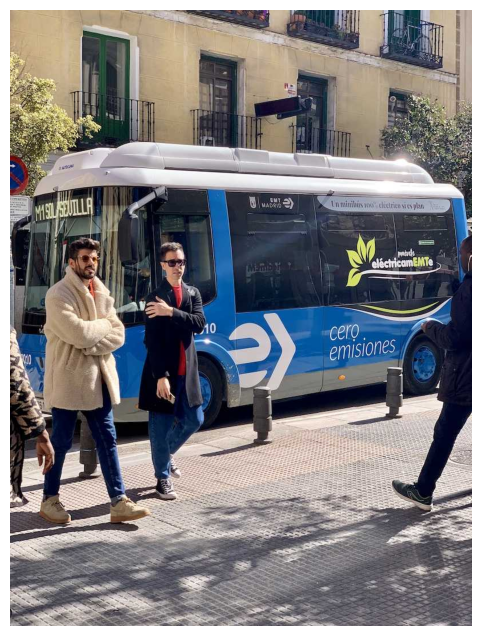

In [3]:
url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"
urllib.request.urlretrieve(url, "bus.jpg")

img = cv2.imread("bus.jpg")                  # OpenCV loads colours as B, G, R
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # convert to the normal R, G, B order
print("Shape (height, width, channels):", img.shape)
print("Total numbers:", img.size)
print("Top-left pixel [R, G, B]:", img[0, 0])

plt.figure(figsize=(6, 8)); plt.imshow(img); plt.axis("off"); plt.show()

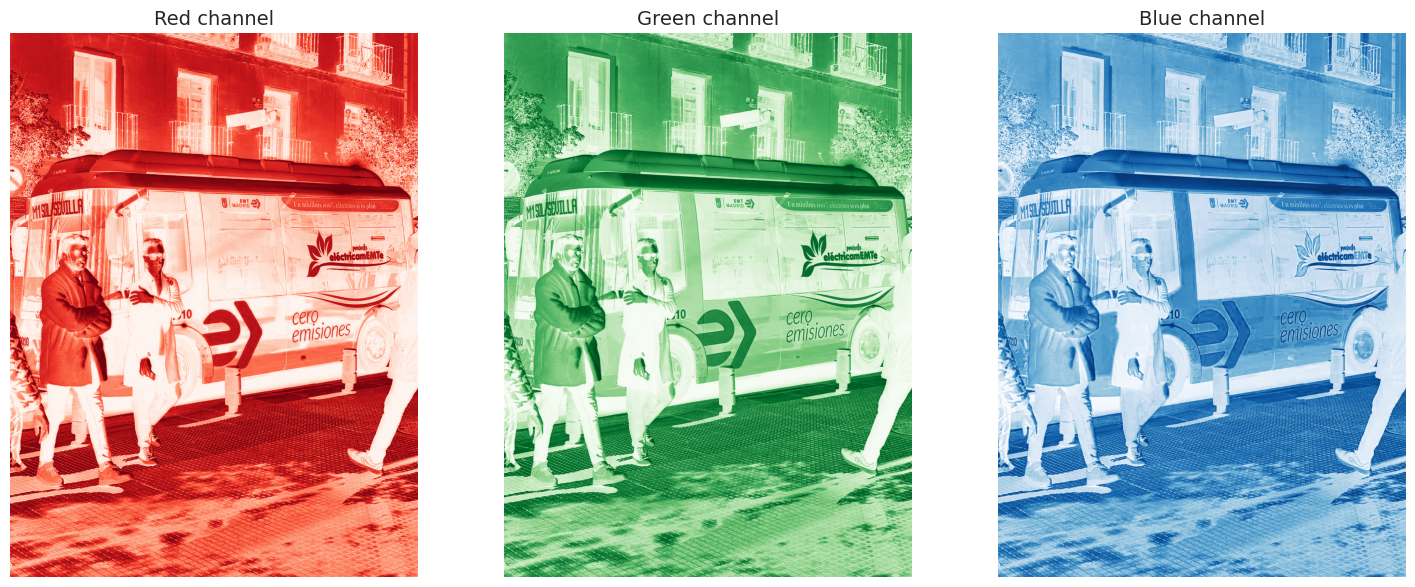

In [4]:
# The three colour channels, shown separately
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for i, (ax, name, cmap) in enumerate(zip(axes, ["Red", "Green", "Blue"], ["Reds", "Greens", "Blues"])):
    ax.imshow(img[:, :, i], cmap=cmap); ax.set_title(name + " channel", fontsize=14); ax.axis("off")
plt.tight_layout(); plt.show()

🧠 This photo is about **2.6 million numbers**. A dense layer of 128 neurons on it would need **335 million weights** — far too many. CNNs solve this by re-using small filters.

---
## Part 2 · Convolution: a sliding pattern detector
A **filter** (kernel) is a tiny grid of weights, e.g. 3×3. We slide it over the image; at each spot we multiply and add up. The result is a **feature map** that lights up wherever the pattern appears.

This filter finds **vertical edges** (dark on the left, bright on the right):

In [5]:
vertical_edge = np.array([[-1, 0, 1],
                          [-1, 0, 1],
                          [-1, 0, 1]], dtype=np.float32)
horizontal_edge = vertical_edge.T      # flip it: finds horizontal edges

# A tiny 6x6 test image: dark left half, bright right half
tiny = np.array([[0, 0, 0, 9, 9, 9]] * 6, dtype=np.float32)
out = cv2.filter2D(tiny, -1, vertical_edge, borderType=cv2.BORDER_CONSTANT)
print("Image:\n", tiny)
print("Feature map (big numbers = edge found):\n", out)

Image:
 [[0. 0. 0. 9. 9. 9.]
 [0. 0. 0. 9. 9. 9.]
 [0. 0. 0. 9. 9. 9.]
 [0. 0. 0. 9. 9. 9.]
 [0. 0. 0. 9. 9. 9.]
 [0. 0. 0. 9. 9. 9.]]
Feature map (big numbers = edge found):
 [[  0.   0.  18.  18.   0. -18.]
 [  0.   0.  27.  27.   0. -27.]
 [  0.   0.  27.  27.   0. -27.]
 [  0.   0.  27.  27.   0. -27.]
 [  0.   0.  27.  27.   0. -27.]
 [  0.   0.  18.  18.   0. -18.]]


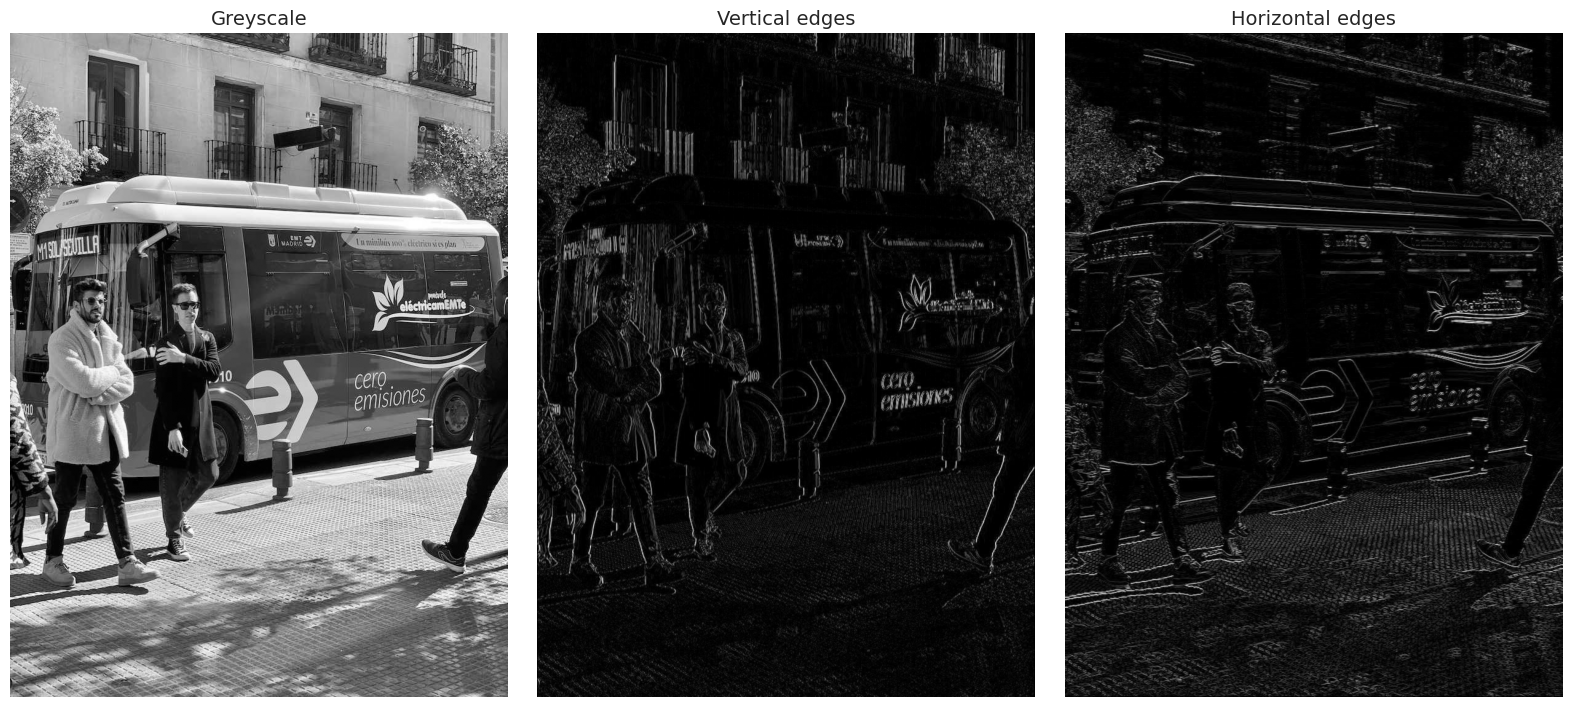

In [6]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)

v = np.abs(cv2.filter2D(gray, -1, vertical_edge))
h = np.abs(cv2.filter2D(gray, -1, horizontal_edge))

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
axes[0].imshow(gray, cmap="gray"); axes[0].set_title("Greyscale", fontsize=14)
axes[1].imshow(v, cmap="gray"); axes[1].set_title("Vertical edges", fontsize=14)
axes[2].imshow(h, cmap="gray"); axes[2].set_title("Horizontal edges", fontsize=14)
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

🧠 Look at the bus windows and the poles: the vertical-edge filter lights up on upright lines, the horizontal one on the roof and window bottoms.

**Key idea:** in a CNN nobody designs the filters — they are **weights, learned by training**. The first layer usually learns edge detectors just like these.

✍️ **Exercise 1:** try a **blur** filter `np.ones((5, 5)) / 25` and a **sharpen** filter `[[0,-1,0],[-1,5,-1],[0,-1,0]]` on `gray`.

### Max pooling
After convolution we shrink the feature map: split it into 2×2 blocks and keep the **biggest** number in each.

In [7]:
fm = np.array([[1, 3, 2, 0],
               [5, 2, 1, 7],
               [0, 1, 4, 2],
               [6, 2, 3, 1]])
pooled = fm.reshape(2, 2, 2, 2).max(axis=(1, 3))
print("Feature map:\n", fm)
print("After 2x2 max pooling:\n", pooled)

Feature map:
 [[1 3 2 0]
 [5 2 1 7]
 [0 1 4 2]
 [6 2 3 1]]
After 2x2 max pooling:
 [[5 7]
 [6 4]]


---
## Part 3 · Train a CNN on Fashion-MNIST
Same data as Notebook 1.

In [8]:
import gzip, urllib.request

BASE = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"

def load_fashion(kind):
    """Download one half (train or t10k) of Fashion-MNIST straight from the official GitHub repo."""
    raw_imgs = urllib.request.urlopen(BASE + f"{kind}-images-idx3-ubyte.gz").read()
    raw_labs = urllib.request.urlopen(BASE + f"{kind}-labels-idx1-ubyte.gz").read()
    imgs = np.frombuffer(gzip.decompress(raw_imgs), np.uint8, offset=16).reshape(-1, 28, 28)
    labs = np.frombuffer(gzip.decompress(raw_labs), np.uint8, offset=8)
    return imgs, labs

X_train_raw, y_train = load_fashion("train")
X_test_raw,  y_test  = load_fashion("t10k")

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Training images:", X_train_raw.shape)   # (60000, 28, 28)
print("Test images:    ", X_test_raw.shape)    # (10000, 28, 28)

Training images: (60000, 28, 28)
Test images:     (10000, 28, 28)


In [9]:
# CNNs expect a channel dimension: (28, 28) -> (28, 28, 1)   (1 channel = greyscale)
X_train = (X_train_raw.astype("float32") / 255.0)[..., None]
X_test  = (X_test_raw.astype("float32") / 255.0)[..., None]
print(X_train.shape)

(60000, 28, 28, 1)


Our CNN — the one from the slides:
- **Conv2D(32, 3)** → 32 filters of size 3×3 → **MaxPooling** →
- **Conv2D(64, 3)** → 64 filters → **MaxPooling** →
- **Flatten → Dense(128) → Dropout(0.3) → Dense(10, softmax)**

In [10]:
keras.utils.set_random_seed(42)
cnn = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu", name="conv1"),
    layers.MaxPooling2D(2, name="pool1"),
    layers.Conv2D(64, 3, activation="relu", name="conv2"),
    layers.MaxPooling2D(2, name="pool2"),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
])
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

🧠 Look at the **Param #** column: the 32 filters of conv1 need only **320** weights (32 × 3×3 + 32 biases). Filters are small and re-used everywhere in the image.

⏳ Training: under a minute on GPU, ~3 minutes on CPU.

In [11]:
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h_cnn = cnn.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8050 - loss: 0.5407 - val_accuracy: 0.8580 - val_loss: 0.3955
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8717 - loss: 0.3528 - val_accuracy: 0.8800 - val_loss: 0.3256
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8869 - loss: 0.3070 - val_accuracy: 0.8853 - val_loss: 0.3087
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8982 - loss: 0.2759 - val_accuracy: 0.8933 - val_loss: 0.2919
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9059 - loss: 0.2514 - val_accuracy: 0.8975 - val_loss: 0.2762
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9137 - loss: 0.2300 - val_accuracy: 0.9083 - val_loss: 0.2559
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9202 - loss: 0.2140 - val_accuracy: 0.9105 - val_loss: 0.2515
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9277 - loss: 0.1953 - val_accuracy: 0

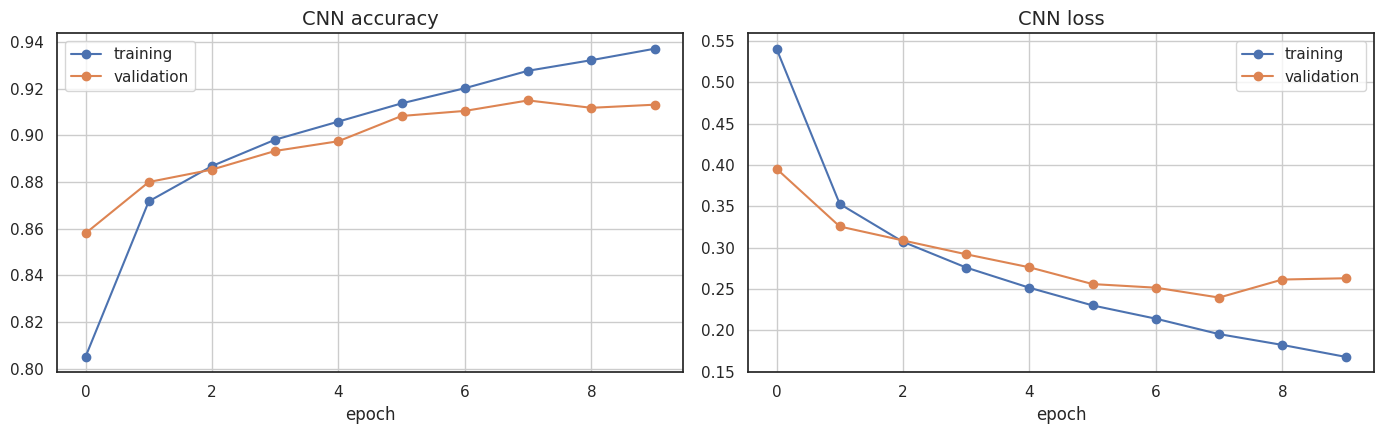

CNN test accuracy: 90.9%   (dense network in Notebook 1: about 87%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(h_cnn.history["accuracy"], "o-", label="training"); axes[0].plot(h_cnn.history["val_accuracy"], "o-", label="validation")
axes[0].set_title("CNN accuracy", fontsize=14); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(True)
axes[1].plot(h_cnn.history["loss"], "o-", label="training"); axes[1].plot(h_cnn.history["val_loss"], "o-", label="validation")
axes[1].set_title("CNN loss", fontsize=14); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

test_acc = cnn.evaluate(X_test, y_test, verbose=0)[1]
print(f"CNN test accuracy: {test_acc:.1%}   (dense network in Notebook 1: about 87%)")

In [13]:
from sklearn.metrics import confusion_matrix
y_pred = cnn.predict(X_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
per_class = cm.diagonal() / cm.sum(axis=1)
dense_nb1 = [91.5, 96.4, 81.7, 93.6, 72.5, 95.6, 53.8, 96.9, 95.6, 93.7]   # from Notebook 1 (our run)
print(f"{'class':11s}  dense   CNN")
for name, d, c in zip(class_names, dense_nb1, per_class):
    print(f"{name:11s}  {d:5.1f}%  {100*c:5.1f}%")

class        dense   CNN
T-shirt       91.5%   88.9%
Trouser       96.4%   97.6%
Pullover      81.7%   91.5%
Dress         93.6%   92.9%
Coat          72.5%   87.3%
Sandal        95.6%   98.9%
Shirt         53.8%   62.1%
Sneaker       96.9%   97.0%
Bag           95.6%   98.4%
Ankle boot    93.7%   94.8%


### Look inside the CNN
What do the 32 filters of the first layer "see"? We feed one image in and show the 32 feature maps.

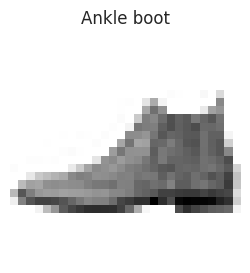

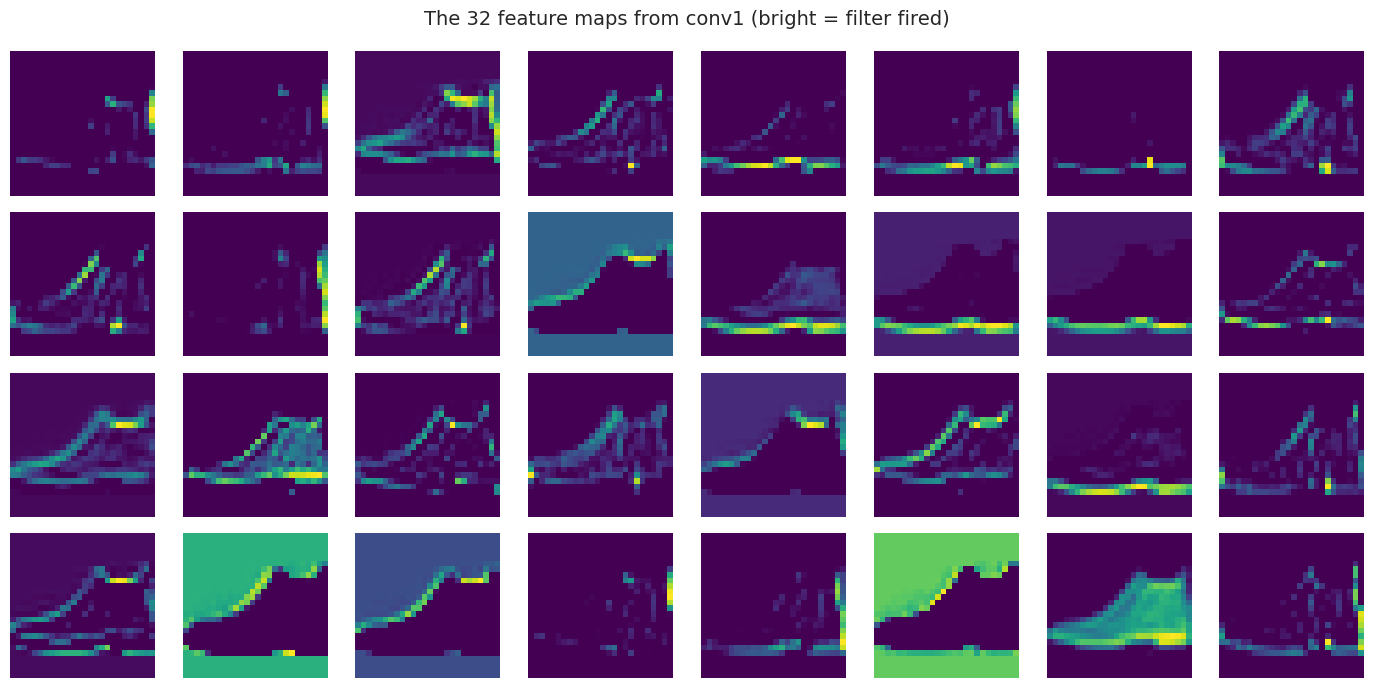

In [14]:
viewer = keras.Model(inputs=cnn.inputs, outputs=cnn.get_layer("conv1").output)
i = 0   # first test image (try others!)
maps = viewer.predict(X_test[i:i+1], verbose=0)[0]     # shape (26, 26, 32)

plt.figure(figsize=(3, 3)); plt.imshow(X_test[i, :, :, 0], cmap="gray_r"); plt.title(class_names[y_test[i]]); plt.axis("off"); plt.show()
plt.figure(figsize=(14, 7))
for k in range(32):
    plt.subplot(4, 8, k + 1); plt.imshow(maps[:, :, k], cmap="viridis"); plt.axis("off")
plt.suptitle("The 32 feature maps from conv1 (bright = filter fired)", fontsize=14)
plt.tight_layout(); plt.show()

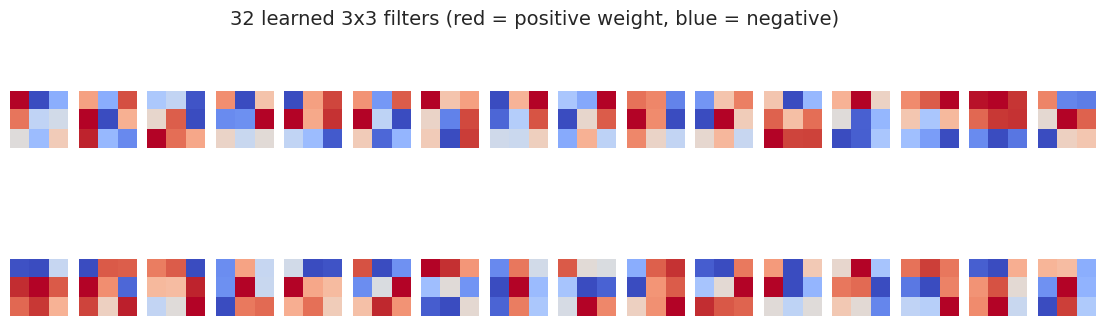

In [15]:
# The learned 3x3 filters themselves
w = cnn.get_layer("conv1").get_weights()[0]    # shape (3, 3, 1, 32)
plt.figure(figsize=(14, 4))
for k in range(32):
    plt.subplot(2, 16, k + 1); plt.imshow(w[:, :, 0, k], cmap="coolwarm"); plt.axis("off")
plt.suptitle("32 learned 3x3 filters (red = positive weight, blue = negative)", fontsize=14)
plt.show()

🧠 Some filters light up on the **outline**, some on the **inside**, some on **left/right** or **top/bottom** edges — edge detectors learned from data, just like the ones we built by hand.

✍️ **Exercise 2:** add a third block `layers.Conv2D(128, 3, activation="relu")` right after `pool2` (no pooling after it). Does the test accuracy improve? How does the number of weights change?

---
## Part 4 · Transfer learning: don't start from zero
Training a strong image model from scratch needs millions of images. Instead we take a model **already trained on ImageNet** (1.2 million photos, 1,000 classes) and **fine-tune** it on our task.

**Our task: Imagenette** — 10 classes of real colour photos (tench fish, springer spaniel dog, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute).

We use **Ultralytics YOLO11**'s classification model and train it twice for **2 epochs**:
1. starting from **pre-trained** ImageNet weights
2. starting from **random** weights (from scratch)

⏳ The dataset (~100 MB) downloads automatically on first use. Each training takes ~1 min on a T4 GPU (3–4 min on CPU). To keep it quick we use small 128-pixel images and half of the training set.

In [16]:
# We run YOLO from the command line ("!yolo ...") so it trains in its own process,
# separate from TensorFlow. Same thing as YOLO("yolo11n-cls.pt").train(...) in Python.
!yolo classify train model=yolo11n-cls.pt data=imagenette160 epochs=2 imgsz=128 batch=64 fraction=0.5 seed=42 plots=False name=pretrained exist_ok=True

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=imagenette160, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.5, freeze=None, hsv_h

In [17]:
# Same architecture (.yaml = just the blueprint), random starting weights
!yolo classify train model=yolo11n-cls.yaml pretrained=False data=imagenette160 epochs=2 imgsz=128 batch=64 fraction=0.5 seed=42 plots=False name=scratch exist_ok=True

YOLO11n-cls summary: 86 layers, 2,812,104 parameters, 2,812,104 gradients, 3.3 GFLOPs
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=imagenette160, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.5, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.yaml, momentum=0.937, mosaic=

pretrained accuracy after each epoch: [0.876, 0.928]
scratch    accuracy after each epoch: [0.171, 0.284]


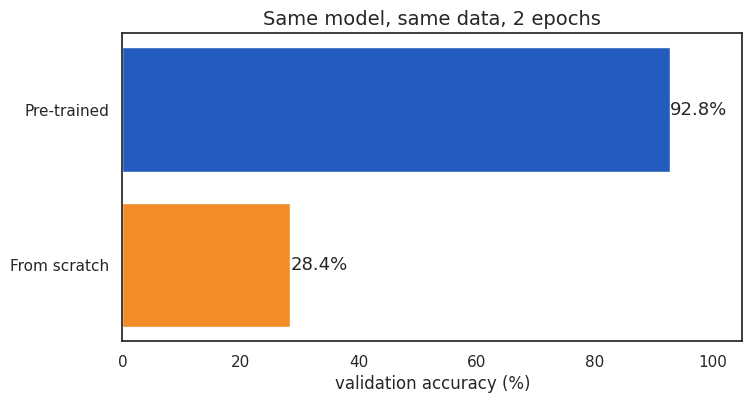

In [18]:
import pandas as pd
res = {}
for name in ["pretrained", "scratch"]:
    df = pd.read_csv(f"runs/classify/{name}/results.csv")
    df.columns = df.columns.str.strip()
    res[name] = df["metrics/accuracy_top1"].iloc[-1]
    print(f"{name:10s} accuracy after each epoch:", df["metrics/accuracy_top1"].round(3).tolist())

plt.figure(figsize=(8, 4))
bars = plt.barh(["From scratch", "Pre-trained"], [100 * res["scratch"], 100 * res["pretrained"]], color=["#F28C28", "#245BBF"])
plt.bar_label(bars, fmt="%.1f%%", fontsize=13)
plt.xlim(0, 105); plt.xlabel("validation accuracy (%)")
plt.title("Same model, same data, 2 epochs", fontsize=14); plt.show()

🧠 Same network, same data, same time — the only difference is the **starting weights**. The pre-trained model already knows edges, textures and shapes, so it only needs to learn the new labels.

Let's use the fine-tuned model on a few validation photos:

In [19]:
import glob, json, random, shutil, os
from pathlib import Path

# Find where Ultralytics saved the dataset
settings = json.load(open(Path.home() / ".config" / "Ultralytics" / "settings.json"))
val_dir = Path(settings["datasets_dir"]) / "imagenette160" / "val"

random.seed(1)
files = random.sample(sorted(glob.glob(str(val_dir / "*" / "*.JPEG"))), 8)
shutil.rmtree("samples", ignore_errors=True); os.makedirs("samples")
for f in files:
    shutil.copy(f, "samples/")

# The dataset's folders use ImageNet codes; the model uses these names
code2name = {"n01440764": "tench", "n02102040": "English_springer", "n02979186": "cassette_player",
             "n03000684": "chain_saw", "n03028079": "church", "n03394916": "French_horn",
             "n03417042": "garbage_truck", "n03425413": "gas_pump", "n03445777": "golf_ball", "n03888257": "parachute"}

In [20]:
!yolo classify predict model=runs/classify/pretrained/weights/best.pt source=samples imgsz=128 save=False save_txt=True name=pred exist_ok=True verbose=False

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,538,834 parameters, 0 gradients, 3.2 GFLOPs
Results saved to /content/runs/classify/pred
8 labels saved to /content/runs/classify/pred/labels
💡 Learn more at https://docs.ultralytics.com/modes/predict


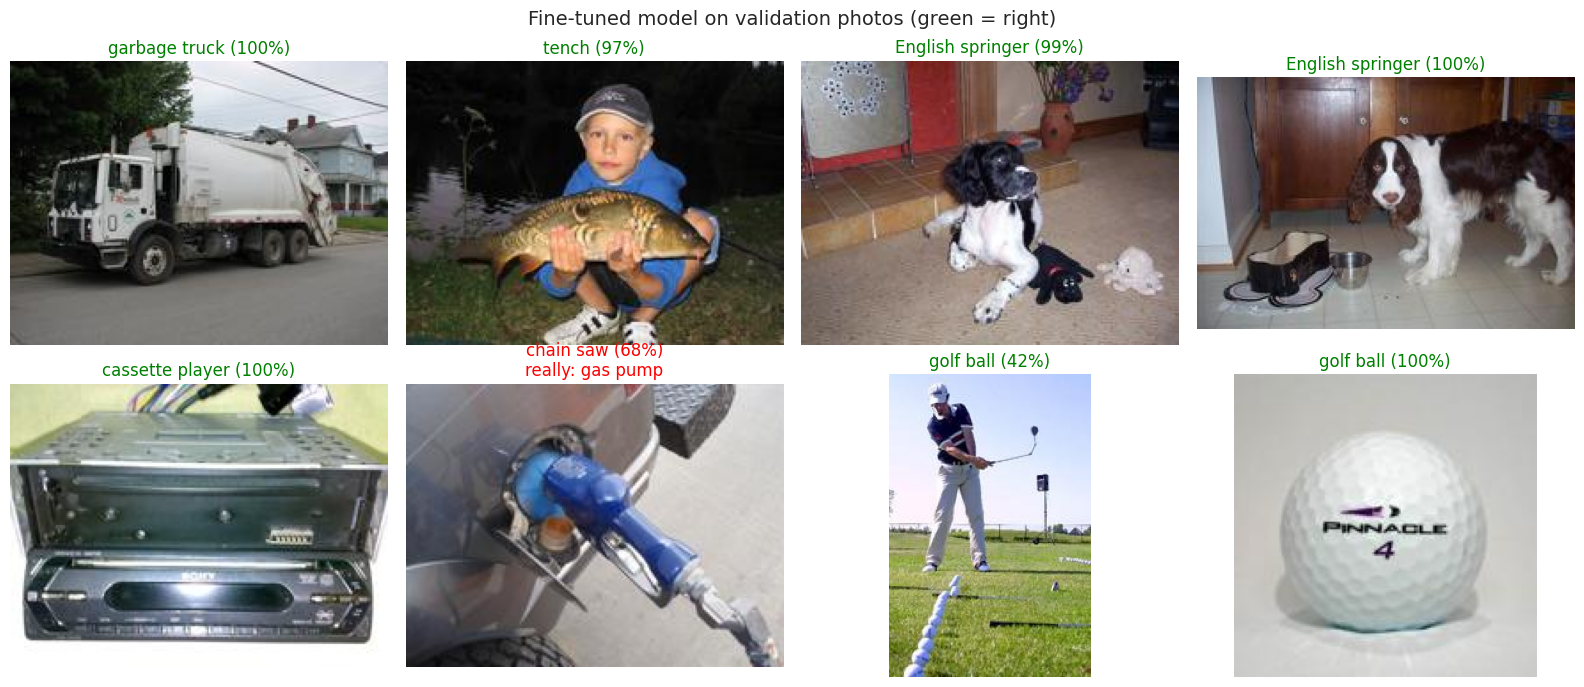

In [21]:
plt.figure(figsize=(16, 7))
for k, f in enumerate(sorted(glob.glob("samples/*.JPEG"))):
    stem = Path(f).stem
    top = open(f"runs/classify/pred/labels/{stem}.txt").readline().split()   # "probability class"
    prob, cls = float(top[0]), top[1]
    true = Path([g for g in files if Path(g).stem == stem][0]).parent.name
    plt.subplot(2, 4, k + 1)
    plt.imshow(cv2.cvtColor(cv2.imread(f), cv2.COLOR_BGR2RGB)); plt.axis("off")
    ok = cls == code2name[true]
    plt.title(f"{cls.replace('_', ' ')} ({prob:.0%})" + ("" if ok else f"\nreally: {code2name[true].replace('_', ' ')}"),
              fontsize=12, color="green" if ok else "red")
plt.suptitle("Fine-tuned model on validation photos (green = right)", fontsize=14)
plt.tight_layout(); plt.show()

🧠 Look at the mistakes (red): what might have confused the model? The dataset's folders are named with ImageNet codes (e.g. `n03888257` = parachute); `code2name` translates them.

**In real projects** you do exactly this with your own folders of images: `data/train/cassava_healthy`, `data/train/cassava_mosaic`, `data/val/...` then `yolo classify train model=yolo11n-cls.pt data=data`. A few hundred photos per class is often enough.

✍️ **Exercise 3:** train the pre-trained model for **5 epochs** with `fraction=1.0` and `imgsz=160`. How high can you get?

---
## ✅ Summary
- Images are grids of numbers (3 per pixel for colour).
- Convolution slides small learned filters over the image; pooling shrinks it.
- Our CNN beat the dense network (~91% vs ~87%) with fewer mistakes on shirts and coats.
- Transfer learning: start from a pre-trained model — far better results with little data and time.

---
## Solutions

In [ ]:
# Exercise 1
blur = cv2.filter2D(gray, -1, np.ones((5, 5), np.float32) / 25)
sharp = cv2.filter2D(gray, -1, np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], np.float32))
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
axes[0].imshow(blur, cmap="gray"); axes[0].set_title("Blur"); axes[1].imshow(np.clip(sharp, 0, 255), cmap="gray"); axes[1].set_title("Sharpen")
for a in axes: a.axis("off")
plt.show()

In [ ]:
# Exercise 2: in our run the third conv layer did NOT help (90.4% vs 91.0%) - deeper is not automatically better.
# Weights change: conv3 adds 73,856, but the flatten output shrinks (3x3x128 = 1,152 instead of 1,600), so the dense layer gets smaller.
keras.utils.set_random_seed(42)
cnn3 = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation="relu"),
    layers.Flatten(), layers.Dense(128, activation="relu"), layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")])
cnn3.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn3.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=0)
print("Weights:", cnn3.count_params(), " test acc: %.1f%%" % (100 * cnn3.evaluate(X_test, y_test, verbose=0)[1]))

In [ ]:
# Exercise 3 (GPU recommended: ~3-4 minutes on T4). Remove the # to run.
# !yolo classify train model=yolo11n-cls.pt data=imagenette160 epochs=5 imgsz=160 batch=64 fraction=1.0 seed=42 plots=False name=pre5 exist_ok=True